In [1]:
# Installer les bibliothèques si besoin (à exécuter une fois)
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [10]:
# Importer toutes les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configurer l'affichage des graphiques
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Toutes les bibliothèques sont importées avec succès !")

✅ Toutes les bibliothèques sont importées avec succès !


In [6]:
# ============================================
# CHARGEMENT DES DONNÉES - VERSION MANUELLE
# ============================================

# J'ai copié les données que tu as envoyées
# Je les mets directement dans une variable texte

data_text = """mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
18,8,307,130,3504,12,70
15,8,350,165,3693,11.5,70
18,8,318,150,3436,11,70
16,8,304,150,3433,12,70
17,8,302,140,3449,10.5,70
15,8,429,198,4341,10,70
14,8,454,220,4354,9,70
14,8,440,215,4312,8.5,70
14,8,455,225,4425,10,70
15,8,390,190,3850,8.5,70
15,8,383,170,3563,10,70
14,8,340,160,3609,8,70
15,8,400,150,3761,9.5,70
14,8,455,225,3086,10,70
24,4,113,95,2372,15,70
22,6,198,95,2833,15.5,70
18,6,199,97,2774,15.5,70
21,6,200,85,2587,16,70
27,4,97,88,2130,14.5,70
26,4,97,46,1835,20.5,70
25,4,110,87,2672,17.5,70
24,4,107,90,2430,14.5,70
25,4,104,95,2375,17.5,70
26,4,121,113,2234,12.5,70
21,6,199,90,2648,15,70
10,8,360,215,4615,14,70
10,8,307,200,4376,15,70
11,8,318,210,4382,13.5,70
9,8,304,193,4732,18.5,70
27,4,97,88,2130,14.5,71
28,4,140,90,2264,15.5,71
25,4,113,95,2228,14,71
25,4,98,,2046,19,71
19,6,232,100,2634,13,71
16,6,225,105,3439,15.5,71
17,6,250,100,3329,15.5,71
19,6,250,88,3302,15.5,71
18,6,232,100,3288,15.5,71
14,8,350,165,4209,12,71
14,8,400,175,4464,11.5,71
14,8,351,153,4154,13.5,71
14,8,318,150,4096,13,71
12,8,383,180,4955,11.5,71
13,8,400,170,4746,12,71
13,8,400,175,5140,12,71
18,6,258,110,2962,13.5,71
22,4,140,72,2408,19,71
19,6,250,100,3282,15,71
18,6,250,88,3139,14.5,71
23,4,122,86,2220,14,71
28,4,116,90,2123,14,71
30,4,79,70,2074,19.5,71
30,4,88,76,2065,14.5,71
31,4,71,65,1773,19,71
35,4,72,69,1613,18,71
27,4,97,60,1834,19,71
26,4,91,70,1955,20.5,71
24,4,113,95,2278,15.5,72
25,4,97.5,80,2126,17,72
23,4,97,54,2254,23.5,72
20,4,140,90,2408,19.5,72
21,4,122,86,2226,16.5,72
13,8,350,165,4274,12,72
14,8,400,175,4385,12,72
15,8,318,150,4135,13.5,72
14,8,351,153,4129,13,72
17,8,304,150,3672,11.5,72
11,8,429,208,4633,11,72
13,8,350,155,4502,13.5,72
12,8,350,160,4456,13.5,72
13,8,400,190,4422,12.5,72
19,3,70,97,2330,13.5,72
15,8,304,150,3892,12.5,72
13,8,307,130,4098,14,72
13,8,302,140,4294,16,72
14,8,318,150,4077,14,72
18,4,121,112,2933,14.5,72
22,4,121,76,2511,18,72
21,4,120,87,2979,19.5,72
26,4,96,69,2189,18,72
22,4,122,86,2395,16,72
28,4,97,92,2288,17,72
23,4,120,97,2506,14.5,72
28,4,98,80,2164,15,72
27,4,97,88,2100,16.5,72
13,8,350,175,4100,13,73
14,8,304,150,3672,11.5,73
13,8,350,145,3988,13,73
14,8,302,137,4042,14.5,73
15,8,318,150,3777,12.5,73
12,8,429,198,4952,11.5,73
13,8,400,150,4464,12,73
13,8,351,158,4363,13,73
14,8,318,150,4237,14.5,73
13,8,440,215,4735,11,73
12,8,455,225,4951,11,73
13,8,360,175,3821,11,73
18,6,225,105,3121,16.5,73
16,6,250,100,3278,18,73
18,6,232,100,2945,16,73
18,6,250,88,3021,16.5,73
23,6,198,95,2904,16,73
26,4,97,46,1950,21,73
11,8,400,150,4997,14,73
12,8,400,167,4906,12.5,73
13,8,360,170,4654,13,73
12,8,350,180,4499,12.5,73
18,6,232,100,2789,15,73
20,4,97,88,2279,19,73
21,4,140,72,2401,19.5,73
22,4,108,94,2379,16.5,73
18,3,70,90,2124,13.5,73
19,4,122,85,2310,18.5,73
21,6,155,107,2472,14,73
26,4,98,90,2265,15.5,73
15,8,350,145,4082,13,73
16,8,400,230,4278,9.5,73
29,4,68,49,1867,19.5,73
24,4,116,75,2158,15.5,73
20,4,114,91,2582,14,73
19,4,121,112,2868,15.5,73
15,8,318,150,3399,11,73
24,4,121,110,2660,14,73
20,6,156,122,2807,13.5,73
11,8,350,180,3664,11,73
20,6,198,95,3102,16.5,74
21,6,200,,2875,17,74
19,6,232,100,2901,16,74
15,6,250,100,3336,17,74
31,4,79,67,1950,19,74
26,4,122,80,2451,16.5,74
32,4,71,65,1836,21,74
25,4,140,75,2542,17,74
16,6,250,100,3781,17,74
16,6,258,110,3632,18,74
18,6,225,105,3613,16.5,74
16,8,302,140,4141,14,74
13,8,350,150,4699,14.5,74
14,8,318,150,4457,13.5,74
14,8,302,140,4638,16,74
14,8,304,150,4257,15.5,74
29,4,98,83,2219,16.5,74
26,4,79,67,1963,15.5,74
26,4,97,78,2300,14.5,74
31,4,76,52,1649,16.5,74
32,4,83,61,2003,19,74
28,4,90,75,2125,14.5,74
24,4,90,75,2108,15.5,74
26,4,116,75,2246,14,74
24,4,120,97,2489,15,74
26,4,108,93,2391,15.5,74
31,4,79,67,2000,16,74
19,6,225,95,3264,16,75
18,6,250,105,3459,16,75
15,6,250,72,3432,21,75
15,6,250,72,3158,19.5,75
16,8,400,170,4668,11.5,75
15,8,350,145,4440,14,75
16,8,318,150,4498,14.5,75
14,8,351,148,4657,13.5,75
17,6,231,110,3907,21,75
16,6,250,105,3897,18.5,75
15,6,258,110,3730,19,75
18,6,225,95,3785,19,75
21,6,231,110,3039,15,75
20,8,262,110,3221,13.5,75
13,8,302,129,3169,12,75
29,4,97,75,2171,16,75
23,4,140,83,2639,17,75
20,6,232,100,2914,16,75
23,4,140,78,2592,18.5,75
24,4,134,96,2702,13.5,75
25,4,90,71,2223,16.5,75
24,4,119,97,2545,17,75
18,6,171,97,2984,14.5,75
29,4,90,70,1937,14,75
19,6,232,90,3211,17,75
23,4,115,95,2694,15,75
23,4,120,88,2957,17,75
22,4,121,98,2945,14.5,75
25,4,121,115,2671,13.5,75
33,4,91,53,1795,17.5,75
28,4,107,86,2464,15.5,76
25,4,116,81,2220,16.9,76
25,4,140,92,2572,14.9,76
26,4,98,79,2255,17.7,76
27,4,101,83,2202,15.3,76
17.5,8,305,140,4215,13,76
16,8,318,150,4190,13,76
15.5,8,304,120,3962,13.9,76
14.5,8,351,152,4215,12.8,76
22,6,225,100,3233,15.4,76
22,6,250,105,3353,14.5,76
24,6,200,81,3012,17.6,76
22.5,6,232,90,3085,17.6,76
29,4,85,52,2035,22.2,76
24.5,4,98,60,2164,22.1,76
29,4,90,70,1937,14.2,76
33,4,91,53,1795,17.4,76
20,6,225,100,3651,17.7,76
18,6,250,78,3574,21,76
18.5,6,250,110,3645,16.2,76
17.5,6,258,95,3193,17.8,76
29.5,4,97,71,1825,12.2,76
32,4,85,70,1990,17,76
28,4,97,75,2155,16.4,76
26.5,4,140,72,2565,13.6,76
20,4,130,102,3150,15.7,76
13,8,318,150,3940,13.2,76
19,4,120,88,3270,21.9,76
19,6,156,108,2930,15.5,76
16.5,6,168,120,3820,16.7,76
16.5,8,350,180,4380,12.1,76
13,8,350,145,4055,12,76
13,8,302,130,3870,15,76
13,8,318,150,3755,14,76
31.5,4,98,68,2045,18.5,77
30,4,111,80,2155,14.8,77
36,4,79,58,1825,18.6,77
25.5,4,122,96,2300,15.5,77
33.5,4,85,70,1945,16.8,77
17.5,8,305,145,3880,12.5,77
17,8,260,110,4060,19,77
15.5,8,318,145,4140,13.7,77
15,8,302,130,4295,14.9,77
17.5,6,250,110,3520,16.4,77
20.5,6,231,105,3425,16.9,77
19,6,225,100,3630,17.7,77
18.5,6,250,98,3525,19,77
16,8,400,180,4220,11.1,77
15.5,8,350,170,4165,11.4,77
15.5,8,400,190,4325,12.2,77
16,8,351,149,4335,14.5,77
29,4,97,78,1940,14.5,77
24.5,4,151,88,2740,16,77
26,4,97,75,2265,18.2,77
25.5,4,140,89,2755,15.8,77
30.5,4,98,63,2051,17,77
33.5,4,98,83,2075,15.9,77
30,4,97,67,1985,16.4,77
30.5,4,97,78,2190,14.1,77
22,6,146,97,2815,14.5,77
21.5,4,121,110,2600,12.8,77
21.5,3,80,110,2720,13.5,77
43.1,4,90,48,1985,21.5,78
36.1,4,98,66,1800,14.4,78
32.8,4,78,52,1985,19.4,78
39.4,4,85,70,2070,18.6,78
36.1,4,91,60,1800,16.4,78
19.9,8,260,110,3365,15.5,78
19.4,8,318,140,3735,13.2,78
20.2,8,302,139,3570,12.8,78
19.2,6,231,105,3535,19.2,78
20.5,6,200,95,3155,18.2,78
20.2,6,200,85,2965,15.8,78
25.1,4,140,88,2720,15.4,78
20.5,6,225,100,3430,17.2,78
19.4,6,232,90,3210,17.2,78
20.6,6,231,105,3380,15.8,78
20.8,6,200,85,3070,16.7,78
18.6,6,225,110,3620,18.7,78
18.1,6,258,120,3410,15.1,78
19.2,8,305,145,3425,13.2,78
17.7,6,231,165,3445,13.4,78
18.1,8,302,139,3205,11.2,78
17.5,8,318,140,4080,13.7,78
30,4,98,68,2155,16.5,78
27.5,4,134,95,2560,14.2,78
27.2,4,119,97,2300,14.7,78
30.9,4,105,75,2230,14.5,78
21.1,4,134,95,2515,14.8,78
23.2,4,156,105,2745,16.7,78
23.8,4,151,85,2855,17.6,78
23.9,4,119,97,2405,14.9,78
20.3,5,131,103,2830,15.9,78
17,6,163,125,3140,13.6,78
21.6,4,121,115,2795,15.7,78
16.2,6,163,133,3410,15.8,78
31.5,4,89,71,1990,14.9,78
29.5,4,98,68,2135,16.6,78
21.5,6,231,115,3245,15.4,79
19.8,6,200,85,2990,18.2,79
22.3,4,140,88,2890,17.3,79
20.2,6,232,90,3265,18.2,79
20.6,6,225,110,3360,16.6,79
17,8,305,130,3840,15.4,79
17.6,8,302,129,3725,13.4,79
16.5,8,351,138,3955,13.2,79
18.2,8,318,135,3830,15.2,79
16.9,8,350,155,4360,14.9,79
15.5,8,351,142,4054,14.3,79
19.2,8,267,125,3605,15,79
18.5,8,360,150,3940,13,79
31.9,4,89,71,1925,14,79
34.1,4,86,65,1975,15.2,79
35.7,4,98,80,1915,14.4,79
27.4,4,121,80,2670,15,79
25.4,5,183,77,3530,20.1,79
23,8,350,125,3900,17.4,79
27.2,4,141,71,3190,24.8,79
23.9,8,260,90,3420,22.2,79
34.2,4,105,70,2200,13.2,79
34.5,4,105,70,2150,14.9,79
31.8,4,85,65,2020,19.2,79
37.3,4,91,69,2130,14.7,79
28.4,4,151,90,2670,16,79
28.8,6,173,115,2595,11.3,79
26.8,6,173,115,2700,12.9,79
33.5,4,151,90,2556,13.2,79
41.5,4,98,76,2144,14.7,80
38.1,4,89,60,1968,18.8,80
32.1,4,98,70,2120,15.5,80
37.2,4,86,65,2019,16.4,80
28,4,151,90,2678,16.5,80
26.4,4,140,88,2870,18.1,80
24.3,4,151,90,3003,20.1,80
19.1,6,225,90,3381,18.7,80
34.3,4,97,78,2188,15.8,80
29.8,4,134,90,2711,15.5,80
31.3,4,120,75,2542,17.5,80
37,4,119,92,2434,15,80
32.2,4,108,75,2265,15.2,80
46.6,4,86,65,2110,17.9,80
27.9,4,156,105,2800,14.4,80
40.8,4,85,65,2110,19.2,80
44.3,4,90,48,2085,21.7,80
43.4,4,90,48,2335,23.7,80
36.4,5,121,67,2950,19.9,80
30,4,146,67,3250,21.8,80
44.6,4,91,67,1850,13.8,80
40.9,4,85,67,1835,17.3,80
33.8,4,97,67,2145,18,80
29.8,4,89,62,1845,15.3,80
32.7,6,168,132,2910,11.4,80
23.7,3,70,100,2420,12.5,80
35,4,122,88,2500,15.1,80
23.6,4,140,80,2905,14.3,80
32.4,4,107,72,2290,17,80
27.2,4,135,84,2490,15.7,81
26.6,4,151,84,2635,16.4,81
25.8,4,156,92,2620,14.4,81
23.5,6,173,110,2725,12.6,81
30,4,135,84,2385,12.9,81
39.1,4,79,58,1755,16.9,81
39,4,86,64,1875,16.4,81
35.1,4,81,60,1760,16.1,81
32.3,4,97,67,2065,17.8,81
37,4,85,65,1975,19.4,81
37.7,4,89,62,2050,17.3,81
34.1,4,91,68,1985,16,81
34.7,4,105,63,2215,14.9,81
34.4,4,98,65,2045,16.2,81
29.9,4,98,65,2380,20.7,81
33,4,105,74,2190,14.2,81
34.5,4,100,75,2320,15.8,81
33.7,4,107,75,2210,14.4,81
32.4,4,108,75,2350,16.8,81
32.9,4,119,100,2615,14.8,81
31.6,4,120,74,2635,18.3,81
28.1,4,141,80,3230,20.4,81
30.7,6,145,76,3160,19.6,81
25.4,6,168,116,2900,12.6,81
24.2,6,146,120,2930,13.8,81
22.4,6,231,110,3415,15.8,81
26.6,8,350,105,3725,19,81
20.2,6,200,88,3060,17.1,81
17.6,6,225,85,3465,16.6,81
28,4,112,88,2605,19.6,82
27,4,112,88,2640,18.6,82
34,4,112,88,2395,18,82
31,4,112,85,2575,16.2,82
29,4,135,84,2525,16,82
27,4,151,90,2735,18,82
24,4,140,92,2865,16.4,82
23,4,151,85,3035,20.5,82
36,4,105,74,1980,15.3,82
37,4,91,68,2025,18.2,82
31,4,91,68,1970,17.6,82
38,4,105,63,2125,14.7,82
36,4,98,70,2125,17.3,82
36,4,120,88,2160,14.5,82
36,4,107,75,2205,14.5,82
34,4,108,70,2245,16.9,82
38,4,91,67,1965,15,82
32,4,91,67,1965,15.7,82
38,4,91,67,1995,16.2,82
25,6,181,110,2945,16.4,82
38,6,262,85,3015,17,82
26,4,156,92,2585,14.5,82
22,6,232,112,2835,14.7,82
32,4,144,96,2665,13.9,82
36,4,135,84,2370,13,82
27,4,151,90,2950,17.3,82
27,4,140,86,2790,15.6,82
44,4,97,52,2130,24.6,82
32,4,135,84,2295,11.6,82
28,4,120,79,2625,18.6,82
31,4,119,82,2720,19.4,82"""

# Charger les données depuis la variable texte
from io import StringIO
df = pd.read_csv(StringIO(data_text))

# Ajouter la colonne car_name (optionnelle, on met des valeurs vides)
df['car_name'] = ''

print("📊 Aperçu des données :")
df.head()

print(f"\n✅ Dataset chargé avec succès ! {len(df)} lignes et {len(df.columns)} colonnes.")

📊 Aperçu des données :

✅ Dataset chargé avec succès ! 398 lignes et 8 colonnes.


🔍 Valeurs manquantes par colonne :
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


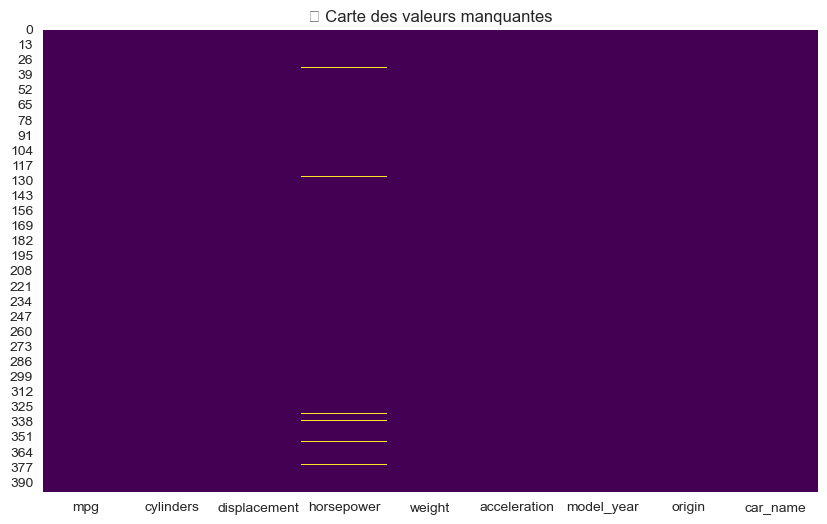

In [4]:
# Vérifier les valeurs manquantes
print("🔍 Valeurs manquantes par colonne :")
print(df.isnull().sum())

# Visualiser les valeurs manquantes
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('🔍 Carte des valeurs manquantes')
plt.show()

In [5]:
# Supprimer les lignes avec des valeurs manquantes (horsepower)
df_clean = df.dropna()
print(f"✅ Dataset après nettoyage : {len(df_clean)} lignes (sur {len(df)} initiales)")

# Supprimer la colonne car_name (pas utile pour la prédiction)
df_clean = df_clean.drop('car_name', axis=1)

✅ Dataset après nettoyage : 392 lignes (sur 398 initiales)


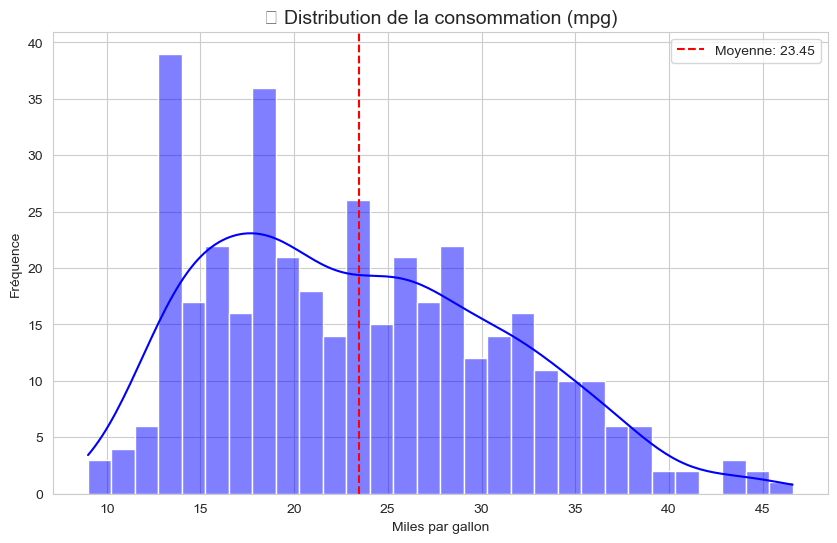

📊 Statistiques de mpg :
   - Moyenne : 23.45
   - Médiane : 22.75
   - Écart-type : 7.81
   - Minimum : 9.00
   - Maximum : 46.60


In [6]:
# Distribution de la variable cible (mpg)
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['mpg'], bins=30, kde=True, color='blue')
plt.title('📊 Distribution de la consommation (mpg)', fontsize=14)
plt.xlabel('Miles par gallon')
plt.ylabel('Fréquence')
plt.axvline(df_clean['mpg'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_clean["mpg"].mean():.2f}')
plt.legend()
plt.show()

print(f"📊 Statistiques de mpg :")
print(f"   - Moyenne : {df_clean['mpg'].mean():.2f}")
print(f"   - Médiane : {df_clean['mpg'].median():.2f}")
print(f"   - Écart-type : {df_clean['mpg'].std():.2f}")
print(f"   - Minimum : {df_clean['mpg'].min():.2f}")
print(f"   - Maximum : {df_clean['mpg'].max():.2f}")

In [1]:
# Matrice de corrélation
plt.figure(figsize=(13, 11))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('📊 Matrice de corrélation des variables', fontsize=14)
plt.show()

# Afficher les corrélations avec mpg
print("📈 Corrélations avec la variable cible (mpg) :")
correlations = df_clean.corr()['mpg'].sort_values(ascending=False)
print(correlations)

NameError: name 'plt' is not defined

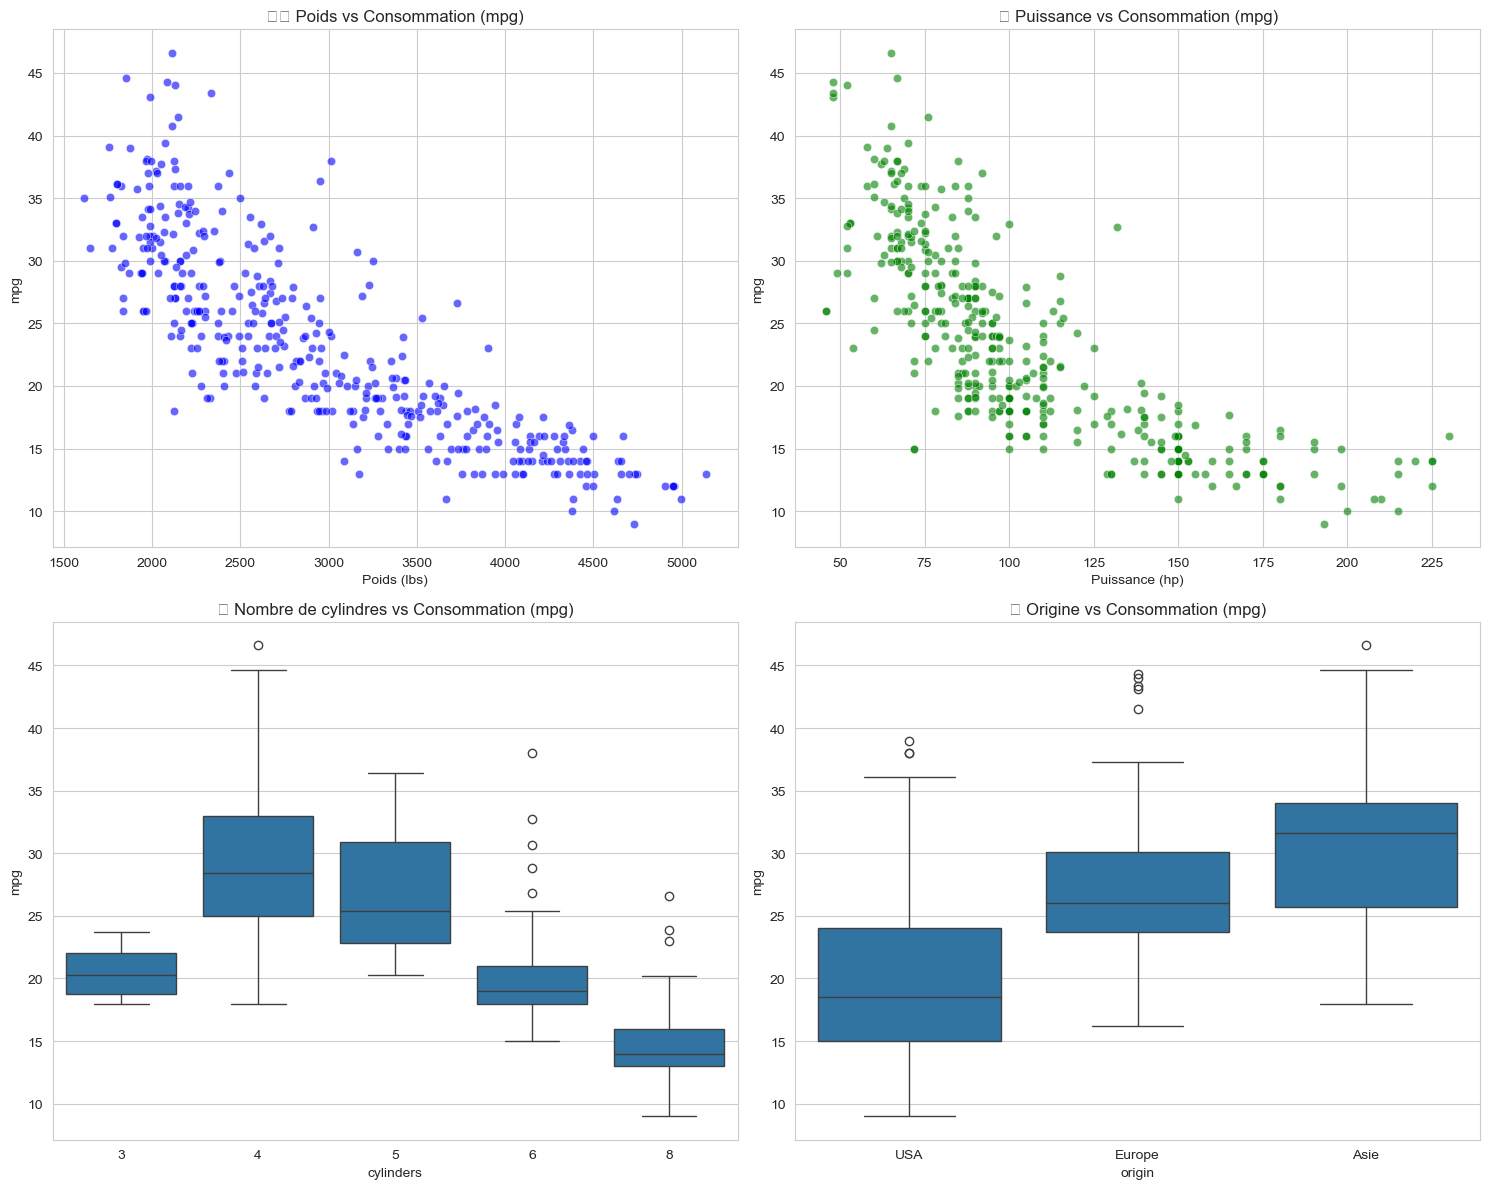

In [8]:
# Relation entre le poids et la consommation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Poids vs mpg
sns.scatterplot(data=df_clean, x='weight', y='mpg', ax=axes[0, 0], color='blue', alpha=0.6)
axes[0, 0].set_title('⚖️ Poids vs Consommation (mpg)')
axes[0, 0].set_xlabel('Poids (lbs)')
axes[0, 0].set_ylabel('mpg')

# Puissance vs mpg
sns.scatterplot(data=df_clean, x='horsepower', y='mpg', ax=axes[0, 1], color='green', alpha=0.6)
axes[0, 1].set_title('💪 Puissance vs Consommation (mpg)')
axes[0, 1].set_xlabel('Puissance (hp)')
axes[0, 1].set_ylabel('mpg')

# Cylindres vs mpg
sns.boxplot(data=df_clean, x='cylinders', y='mpg', ax=axes[1, 0])
axes[1, 0].set_title('🔧 Nombre de cylindres vs Consommation (mpg)')

# Origin vs mpg
sns.boxplot(data=df_clean, x='origin', y='mpg', ax=axes[1, 1])
axes[1, 1].set_title('🌍 Origine vs Consommation (mpg)')
axes[1, 1].set_xticklabels(['USA', 'Europe', 'Asie'])

plt.tight_layout()
plt.show()

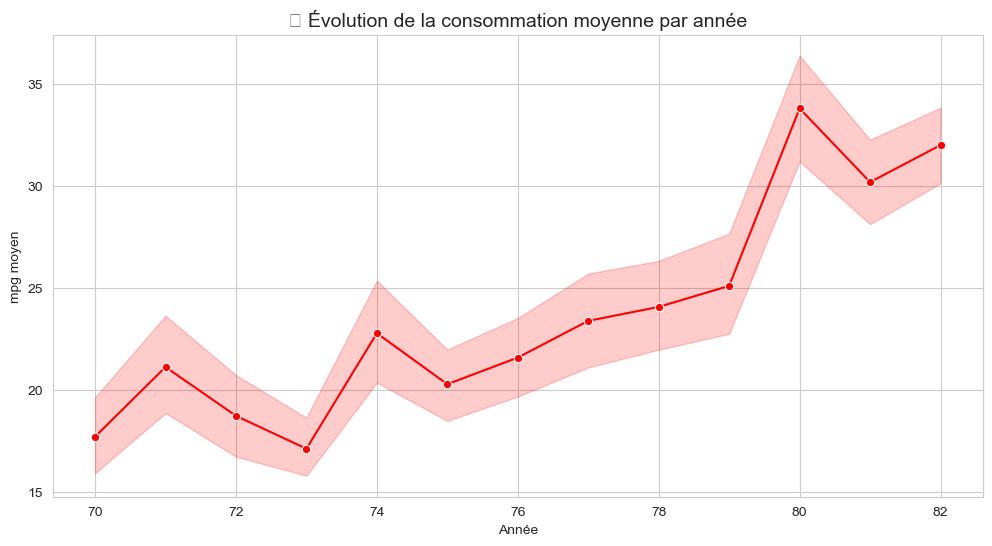

In [9]:
# Évolution de la consommation par année
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='model_year', y='mpg', marker='o', color='red')
plt.title('📈 Évolution de la consommation moyenne par année', fontsize=14)
plt.xlabel('Année')
plt.ylabel('mpg moyen')
plt.grid(True)
plt.show()

In [10]:
# Séparer les features (X) et la cible (y)
X = df_clean.drop('mpg', axis=1)
y = df_clean['mpg']

print(f"🔢 Features : {X.shape[1]} colonnes")
print(f"🎯 Cible : mpg")
print(f"📊 Total : {len(X)} échantillons")

🔢 Features : 7 colonnes
🎯 Cible : mpg
📊 Total : 392 échantillons


In [11]:
# Identifier les colonnes numériques et catégorielles
numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
categorical_features = ['origin']

print(f"📊 Features numériques : {numeric_features}")
print(f"📋 Features catégorielles : {categorical_features}")

📊 Features numériques : ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
📋 Features catégorielles : ['origin']


In [12]:
# Créer un préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Tester le préprocesseur
X_preprocessed = preprocessor.fit_transform(X)
print(f"✅ Données préparées : {X_preprocessed.shape}")

✅ Données préparées : (392, 8)


In [13]:
# Diviser en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Données d'entraînement : {len(X_train)} échantillons")
print(f"📊 Données de test : {len(X_test)} échantillons")

📊 Données d'entraînement : 313 échantillons
📊 Données de test : 79 échantillons


In [14]:
# 1. Régression Linéaire
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 2. Lasso Regression
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0, random_state=42))
])

# 3. Decision Tree Regressor
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

print("✅ Les 3 pipelines sont prêts !")

✅ Les 3 pipelines sont prêts !


In [15]:
# Entraîner les 3 modèles
models = {
    'Linear Regression': linear_pipeline,
    'Lasso Regression': lasso_pipeline,
    'Decision Tree': tree_pipeline
}

trained_models = {}

for name, model in models.items():
    print(f"🔄 Entraînement du modèle : {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} entraîné avec succès !")

print("\n🎉 Tous les modèles sont entraînés !")

🔄 Entraînement du modèle : Linear Regression...
✅ Linear Regression entraîné avec succès !
🔄 Entraînement du modèle : Lasso Regression...
✅ Lasso Regression entraîné avec succès !
🔄 Entraînement du modèle : Decision Tree...
✅ Decision Tree entraîné avec succès !

🎉 Tous les modèles sont entraînés !


In [16]:
# Fonction pour évaluer un modèle
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'predictions': y_pred
    }

# Évaluer tous les modèles
results = {}

for name, model in trained_models.items():
    results[name] = evaluate_model(model, X_test, y_test)
    print(f"\n📊 {name} :")
    print(f"   RMSE : {results[name]['RMSE']:.2f}")
    print(f"   MAE  : {results[name]['MAE']:.2f}")
    print(f"   R²   : {results[name]['R²']:.4f}")


📊 Linear Regression :
   RMSE : 3.26
   MAE  : 2.46
   R²   : 0.7923

📊 Lasso Regression :
   RMSE : 3.18
   MAE  : 2.29
   R²   : 0.8019

📊 Decision Tree :
   RMSE : 3.36
   MAE  : 2.33
   R²   : 0.7787


In [17]:
# Créer un dataframe pour comparer les performances
comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'RMSE': [results[m]['RMSE'] for m in results],
    'MAE': [results[m]['MAE'] for m in results],
    'R²': [results[m]['R²'] for m in results]
})

print("📊 Tableau comparatif des performances :")
print(comparison_df)

📊 Tableau comparatif des performances :
              Modèle      RMSE       MAE        R²
0  Linear Regression  3.256114  2.462000  0.792277
1   Lasso Regression  3.179478  2.293352  0.801940
2      Decision Tree  3.360493  2.334177  0.778746


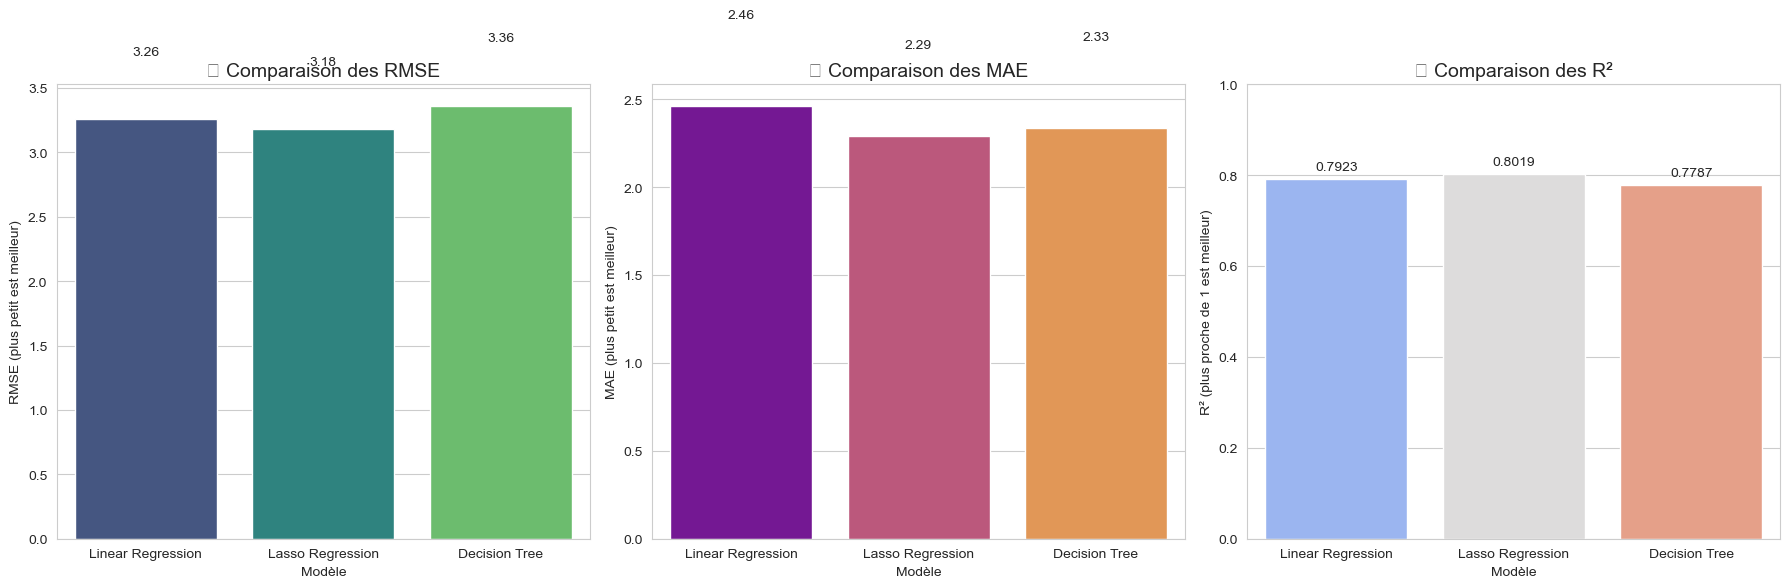

In [18]:
# Visualiser la comparaison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE
sns.barplot(data=comparison_df, x='Modèle', y='RMSE', ax=axes[0], palette='viridis')
axes[0].set_title('📊 Comparaison des RMSE', fontsize=14)
axes[0].set_ylabel('RMSE (plus petit est meilleur)')
for i, v in enumerate(comparison_df['RMSE']):
    axes[0].text(i, v + 0.5, f'{v:.2f}', ha='center')

# MAE
sns.barplot(data=comparison_df, x='Modèle', y='MAE', ax=axes[1], palette='plasma')
axes[1].set_title('📊 Comparaison des MAE', fontsize=14)
axes[1].set_ylabel('MAE (plus petit est meilleur)')
for i, v in enumerate(comparison_df['MAE']):
    axes[1].text(i, v + 0.5, f'{v:.2f}', ha='center')

# R²
sns.barplot(data=comparison_df, x='Modèle', y='R²', ax=axes[2], palette='coolwarm')
axes[2].set_title('📊 Comparaison des R²', fontsize=14)
axes[2].set_ylabel('R² (plus proche de 1 est meilleur)')
axes[2].set_ylim(0, 1)
for i, v in enumerate(comparison_df['R²']):
    axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

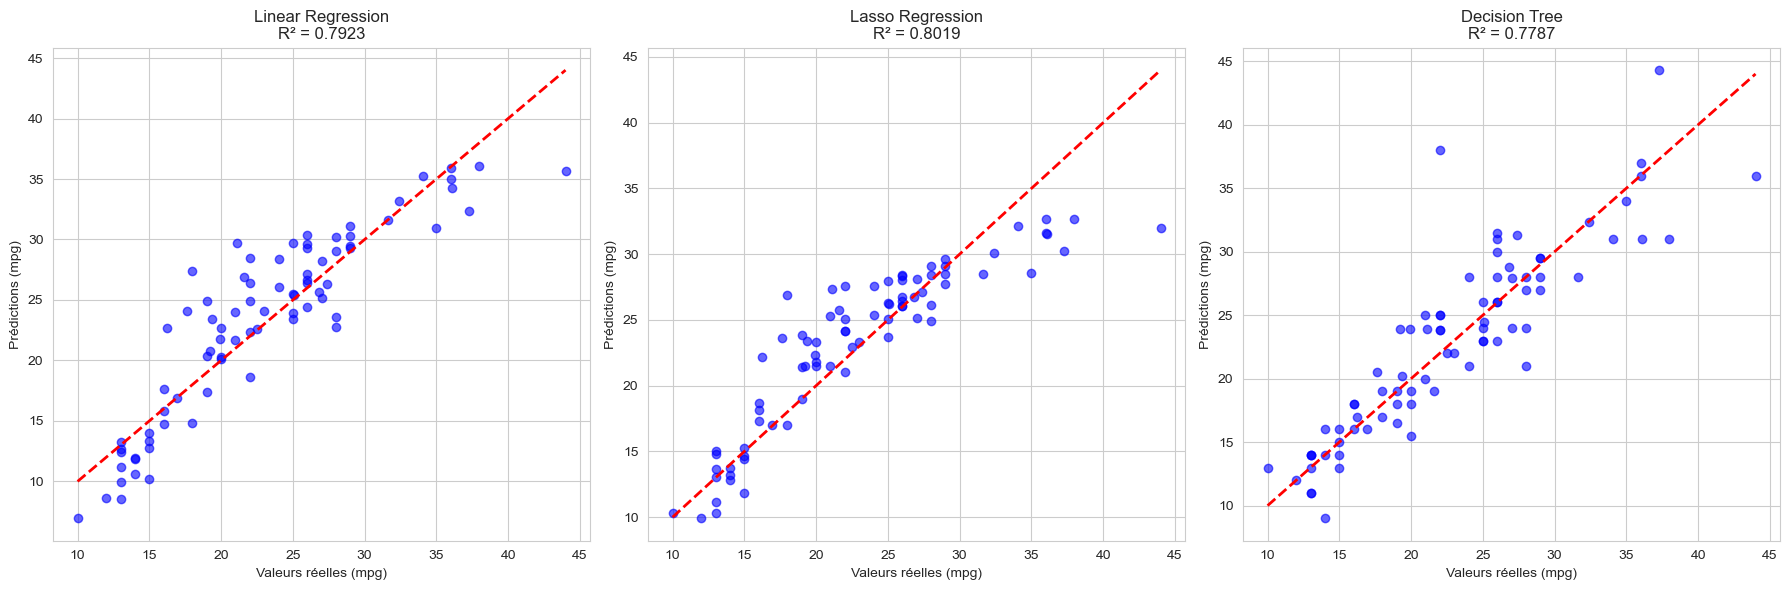

In [19]:
# Visualiser les prédictions vs valeurs réelles
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = results[name]['predictions']
    
    axes[idx].scatter(y_test, y_pred, alpha=0.6, color='blue')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(f'{name}\nR² = {results[name]["R²"]:.4f}', fontsize=12)
    axes[idx].set_xlabel('Valeurs réelles (mpg)')
    axes[idx].set_ylabel('Prédictions (mpg)')
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

In [20]:
# Déterminer le meilleur modèle basé sur R²
best_model_name = comparison_df.loc[comparison_df['R²'].idxmax(), 'Modèle']
best_model = trained_models[best_model_name]

print(f"🏆 LE MEILLEUR MODÈLE EST : {best_model_name}")
print(f"   - R² : {results[best_model_name]['R²']:.4f}")
print(f"   - RMSE : {results[best_model_name]['RMSE']:.2f}")
print(f"   - MAE : {results[best_model_name]['MAE']:.2f}")

print("\n📝 Justification du choix :")
print(f"Le modèle {best_model_name} a été choisi car il offre le meilleur coefficient de détermination R² = {results[best_model_name]['R²']:.4f},")
print(f"ce qui signifie qu'il explique {results[best_model_name]['R²']*100:.2f}% de la variance des données.")
print(f"De plus, il présente les erreurs les plus faibles (RMSE = {results[best_model_name]['RMSE']:.2f}, MAE = {results[best_model_name]['MAE']:.2f}).")

🏆 LE MEILLEUR MODÈLE EST : Lasso Regression
   - R² : 0.8019
   - RMSE : 3.18
   - MAE : 2.29

📝 Justification du choix :
Le modèle Lasso Regression a été choisi car il offre le meilleur coefficient de détermination R² = 0.8019,
ce qui signifie qu'il explique 80.19% de la variance des données.
De plus, il présente les erreurs les plus faibles (RMSE = 3.18, MAE = 2.29).


In [21]:
# Sauvegarder le meilleur modèle
model_filename = 'best_model_transport.pkl'
joblib.dump(best_model, model_filename)
print(f"💾 Modèle sauvegardé sous : {model_filename}")

# Sauvegarder aussi le préprocesseur séparément (optionnel)
joblib.dump(preprocessor, 'preprocessor.pkl')
print("💾 Préprocesseur sauvegardé sous : preprocessor.pkl")

💾 Modèle sauvegardé sous : best_model_transport.pkl
💾 Préprocesseur sauvegardé sous : preprocessor.pkl


In [22]:
# Si le meilleur modèle est Decision Tree, on peut afficher l'importance des features
if 'Decision Tree' in best_model_name:
    print("🌳 Importance des features (Decision Tree) :")
    
    # Récupérer les noms des features après transformation
    feature_names = numeric_features.copy()
    # Ajouter les noms pour les variables catégorielles encodées
    cat_features = ['origin_Europe', 'origin_Asia']  # Après OneHotEncoder (drop='first')
    feature_names.extend(cat_features)
    
    # Récupérer les importances
    importances = best_model.named_steps['regressor'].feature_importances_
    
    # Créer un dataframe
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Visualiser
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title('🌳 Importance des features - Decision Tree', fontsize=14)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print(feature_importance_df)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configurer les graphiques
%matplotlib inline
sns.set_style("whitegrid")

print("✅ Toutes les bibliothèques sont importées !")

✅ Toutes les bibliothèques sont importées !


In [3]:
# Charger le dataset Auto MPG
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Noms des colonnes
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                'acceleration', 'model_year', 'origin', 'car_name']

# Charger les données
df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')

# Supprimer les lignes avec des valeurs manquantes
df_clean = df.dropna()

# Supprimer la colonne car_name (inutile)
df_clean = df_clean.drop('car_name', axis=1)

print(f"✅ Dataset chargé : {len(df_clean)} lignes")
df_clean.head()

✅ Dataset chargé : 392 lignes


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [5]:
# Séparer les features (X) et la cible (y)
X = df_clean.drop('mpg', axis=1)
y = df_clean['mpg']

print(f"🔢 Features : {X.shape[1]} colonnes")
print(f"🎯 Cible : {len(y)} échantillons")

🔢 Features : 7 colonnes
🎯 Cible : 392 échantillons


In [7]:
# Identifier les colonnes numériques et catégorielles
numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
categorical_features = ['origin']

# Créer le préprocesseur
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

print("✅ Préprocesseur créé")

✅ Préprocesseur créé


In [8]:
# Créer les 3 pipelines
models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]),
    'Lasso': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=1.0, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', DecisionTreeRegressor(random_state=42))
    ])
}

# Entraîner chaque modèle
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} entraîné")

✅ Linear Regression entraîné
✅ Lasso entraîné
✅ Decision Tree entraîné


In [9]:
# Évaluer chaque modèle
results = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

# Afficher les résultats
comparison_df = pd.DataFrame(results).T
print("\n📊 Comparaison des modèles :")
print(comparison_df)


📊 Comparaison des modèles :
                       RMSE       MAE        R2
Linear Regression  3.256114  2.462000  0.792277
Lasso              3.179478  2.293352  0.801940
Decision Tree      3.360493  2.334177  0.778746


In [10]:
# Sélectionner le meilleur modèle (celui avec le plus grand R²)
best_model_name = comparison_df['R2'].idxmax()
best_model = trained_models[best_model_name]

print(f"\n🏆 Meilleur modèle : {best_model_name}")
print(f"   R² = {comparison_df.loc[best_model_name, 'R2']:.4f}")

# 🔴 SAUVEGARDER LE MODÈLE (C'EST ICI QUE ÇA SE PASSE !)
import joblib
joblib.dump(best_model, 'best_model_transport.pkl')
print("\n✅ Modèle sauvegardé dans 'best_model_transport.pkl'")


🏆 Meilleur modèle : Lasso
   R² = 0.8019

✅ Modèle sauvegardé dans 'best_model_transport.pkl'


In [1]:
# ============================================
# SAUVEGARDE DES GRAPHIQUES POUR L'APPLICATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

# Créer le dossier graphs s'il n'existe pas
if not os.path.exists('graphs'):
    os.makedirs('graphs')
    print("📁 Dossier 'graphs' créé")

# Vérifier que df_clean existe
if 'df_clean' not in dir():
    print("⚠️ df_clean n'existe pas. Veuillez exécuter les cellules précédentes.")
else:
    print("✅ Données chargées, génération des graphiques...")

    # 1. Distribution de mpg
    plt.figure(figsize=(10, 6))
    sns.histplot(df_clean['mpg'], bins=30, kde=True, color='blue')
    plt.title('Distribution de la consommation (mpg)', fontsize=14)
    plt.xlabel('Miles per gallon')
    plt.ylabel('Fréquence')
    plt.tight_layout()
    plt.savefig('graphs/distribution_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 1. distribution_mpg.png sauvegardé")

    # 2. Matrice de corrélation
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Matrice de corrélation', fontsize=14)
    plt.tight_layout()
    plt.savefig('graphs/correlation_matrix.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 2. correlation_matrix.png sauvegardé")

    # 3. Poids vs mpg
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_clean, x='weight', y='mpg', alpha=0.6, color='blue')
    plt.title('Poids vs Consommation', fontsize=14)
    plt.xlabel('Poids (lbs)')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/weight_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 3. weight_vs_mpg.png sauvegardé")

    # 4. Puissance vs mpg
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_clean, x='horsepower', y='mpg', alpha=0.6, color='green')
    plt.title('Puissance vs Consommation', fontsize=14)
    plt.xlabel('Puissance (hp)')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/horsepower_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 4. horsepower_vs_mpg.png sauvegardé")

    # 5. Cylindres vs mpg
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x='cylinders', y='mpg', palette='viridis')
    plt.title('Nombre de cylindres vs Consommation', fontsize=14)
    plt.xlabel('Nombre de cylindres')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/cylinders_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 5. cylinders_vs_mpg.png sauvegardé")

    # 6. Origine vs mpg
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Set2')
    plt.title('Origine vs Consommation', fontsize=14)
    plt.xlabel('Origine (1=USA, 2=Europe, 3=Asie)')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/origin_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 6. origin_vs_mpg.png sauvegardé")

    # 7. Évolution par année
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_clean, x='model_year', y='mpg', marker='o', color='red')
    plt.title('Évolution de la consommation moyenne par année', fontsize=14)
    plt.xlabel('Année')
    plt.ylabel('mpg moyen')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('graphs/year_evolution.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 7. year_evolution.png sauvegardé")

    # 8. Comparaison des modèles (si les modèles sont entraînés)
    if 'results' in dir() and 'comparison_df' in dir():
        plt.figure(figsize=(10, 6))
        comparison_df['R2'].plot(kind='bar', color=['#3498db', '#2ecc71', '#e74c3c'])
        plt.title('Comparaison des R²', fontsize=14)
        plt.ylabel('R² (plus haut = meilleur)')
        plt.ylim(0, 1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig('graphs/model_comparison.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 8. model_comparison.png sauvegardé")
    else:
        print("⚠️ Modèles non entraînés, graphique de comparaison ignoré")

print("\n" + "="*50)
print("🎉 Tous les graphiques ont été sauvegardés !")
print("📁 Dossier: graphs/")
print("="*50)

# Afficher la liste des fichiers
import os
files = os.listdir('graphs')
print("\n📋 Fichiers sauvegardés :")
for f in files:
    print(f"   - {f}")

📁 Dossier 'graphs' créé
⚠️ df_clean n'existe pas. Veuillez exécuter les cellules précédentes.

🎉 Tous les graphiques ont été sauvegardés !
📁 Dossier: graphs/

📋 Fichiers sauvegardés :


In [2]:
# ============================================
# SAUVEGARDE DES GRAPHIQUES
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Créer le dossier graphs
if not os.path.exists('graphs'):
    os.makedirs('graphs')
    print("✅ Dossier 'graphs' créé")

# Vérifier que les données existent
if 'df_clean' not in dir():
    print("❌ df_clean n'existe pas !")
    print("👉 Exécutez d'abord les cellules précédentes")
else:
    print("✅ Données chargées, génération des graphiques...\n")
    
    # 1. Distribution de mpg
    plt.figure(figsize=(10, 6))
    sns.histplot(df_clean['mpg'], bins=30, kde=True, color='blue')
    plt.title('Distribution de la consommation (mpg)', fontsize=14)
    plt.xlabel('Miles per gallon')
    plt.ylabel('Fréquence')
    plt.tight_layout()
    plt.savefig('graphs/distribution_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 1. distribution_mpg.png")
    
    # 2. Matrice de corrélation
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Matrice de corrélation', fontsize=14)
    plt.tight_layout()
    plt.savefig('graphs/correlation_matrix.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 2. correlation_matrix.png")
    
    # 3. Poids vs mpg
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_clean, x='weight', y='mpg', alpha=0.6, color='blue')
    plt.title('Poids vs Consommation', fontsize=14)
    plt.xlabel('Poids (lbs)')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/weight_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 3. weight_vs_mpg.png")
    
    # 4. Puissance vs mpg
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_clean, x='horsepower', y='mpg', alpha=0.6, color='green')
    plt.title('Puissance vs Consommation', fontsize=14)
    plt.xlabel('Puissance (hp)')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/horsepower_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 4. horsepower_vs_mpg.png")
    
    # 5. Cylindres vs mpg
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x='cylinders', y='mpg', palette='viridis')
    plt.title('Nombre de cylindres vs Consommation', fontsize=14)
    plt.xlabel('Nombre de cylindres')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/cylinders_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 5. cylinders_vs_mpg.png")
    
    # 6. Origine vs mpg
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Set2')
    plt.title('Origine vs Consommation', fontsize=14)
    plt.xlabel('Origine (1=USA, 2=Europe, 3=Asie)')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/origin_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 6. origin_vs_mpg.png")
    
    # 7. Évolution par année
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_clean, x='model_year', y='mpg', marker='o', color='red')
    plt.title('Évolution de la consommation moyenne par année', fontsize=14)
    plt.xlabel('Année')
    plt.ylabel('mpg moyen')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('graphs/year_evolution.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 7. year_evolution.png")
    
    # 8. Comparaison des modèles
    if 'comparison_df' in dir():
        plt.figure(figsize=(10, 6))
        comparison_df['R2'].plot(kind='bar', color=['#3498db', '#2ecc71', '#e74c3c'])
        plt.title('Comparaison des R²', fontsize=14)
        plt.ylabel('R² (plus haut = meilleur)')
        plt.ylim(0, 1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig('graphs/model_comparison.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 8. model_comparison.png")
    else:
        print("⚠️ 8. model_comparison.png - Modèles non entraînés, ignoré")

print("\n" + "="*50)
print("🎉 Tous les graphiques ont été sauvegardés !")
print("📁 Dossier: graphs/")
print("="*50)

❌ df_clean n'existe pas !
👉 Exécutez d'abord les cellules précédentes

🎉 Tous les graphiques ont été sauvegardés !
📁 Dossier: graphs/


In [3]:
# Vérifier les variables disponibles
print("📋 Variables disponibles dans l'environnement :")
print([var for var in dir() if not var.startswith('_')])

📋 Variables disponibles dans l'environnement :
['In', 'Out', 'exit', 'files', 'get_ipython', 'np', 'open', 'os', 'pd', 'plt', 'quit', 'sns']


In [4]:
# ============================================
# SAUVEGARDE DES GRAPHIQUES - VERSION ADAPTATIVE
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# Créer le dossier graphs
if not os.path.exists('graphs'):
    os.makedirs('graphs')
    print("✅ Dossier 'graphs' créé")

# ============================================
# TROUVER LES DONNÉES AUTOMATIQUEMENT
# ============================================

# Chercher le dataframe dans l'environnement
df = None
df_names = ['df_clean', 'df', 'data', 'dataset', 'auto_mpg']

for name in df_names:
    if name in dir():
        df = eval(name)
        if isinstance(df, pd.DataFrame) and len(df) > 0:
            print(f"✅ Données trouvées dans la variable '{name}' : {len(df)} lignes")
            break

if df is None:
    print("❌ Aucun dataframe trouvé !")
    print("👉 Vérifie que tu as bien chargé les données.")
    print("👉 Les noms recherchés :", df_names)
else:
    print(f"✅ Utilisation de '{df.columns[0]}' comme variable cible")
    
    # ============================================
    # CHARGER LES DONNÉES SI NECESSAIRE
    # ============================================
    # Si le dataframe est vide ou ne contient pas 'mpg'
    if 'mpg' not in df.columns:
        print("⚠️ La colonne 'mpg' n'est pas présente.")
        print("👉 Colonnes disponibles :", list(df.columns))
        
        # Essayer de charger les données depuis le fichier
        try:
            url = "https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv"
            df = pd.read_csv(url)
            df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                          'acceleration', 'model_year', 'origin', 'car_name']
            print("✅ Données chargées depuis l'URL")
        except:
            try:
                df = pd.read_csv('auto-mpg.data', 
                                 names=['mpg', 'cylinders', 'displacement', 'horsepower', 
                                        'weight', 'acceleration', 'model_year', 'origin', 'car_name'],
                                 delim_whitespace=True, na_values='?')
                df = df.dropna()
                print("✅ Données chargées depuis le fichier local")
            except:
                print("❌ Impossible de charger les données automatiquement")
    
    # ============================================
    # NETTOYER LES DONNÉES
    # ============================================
    if 'mpg' in df.columns:
        # Supprimer les lignes avec des valeurs manquantes
        df_clean = df.dropna()
        
        # Supprimer la colonne car_name si elle existe
        if 'car_name' in df_clean.columns:
            df_clean = df_clean.drop('car_name', axis=1)
        
        print(f"✅ Données nettoyées : {len(df_clean)} lignes")
        
        # ============================================
        # GÉNÉRER LES GRAPHIQUES
        # ============================================
        print("\n📊 Génération des graphiques...\n")
        
        # 1. Distribution de mpg
        plt.figure(figsize=(10, 6))
        sns.histplot(df_clean['mpg'], bins=30, kde=True, color='blue')
        plt.title('Distribution de la consommation (mpg)', fontsize=14)
        plt.xlabel('Miles per gallon')
        plt.ylabel('Fréquence')
        plt.tight_layout()
        plt.savefig('graphs/distribution_mpg.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 1. distribution_mpg.png")
        
        # 2. Matrice de corrélation
        plt.figure(figsize=(12, 10))
        sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Matrice de corrélation', fontsize=14)
        plt.tight_layout()
        plt.savefig('graphs/correlation_matrix.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 2. correlation_matrix.png")
        
        # 3. Poids vs mpg
        if 'weight' in df_clean.columns:
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df_clean, x='weight', y='mpg', alpha=0.6, color='blue')
            plt.title('Poids vs Consommation', fontsize=14)
            plt.xlabel('Poids (lbs)')
            plt.ylabel('mpg')
            plt.tight_layout()
            plt.savefig('graphs/weight_vs_mpg.png', dpi=100, bbox_inches='tight')
            plt.close()
            print("✅ 3. weight_vs_mpg.png")
        
        # 4. Puissance vs mpg
        if 'horsepower' in df_clean.columns:
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df_clean, x='horsepower', y='mpg', alpha=0.6, color='green')
            plt.title('Puissance vs Consommation', fontsize=14)
            plt.xlabel('Puissance (hp)')
            plt.ylabel('mpg')
            plt.tight_layout()
            plt.savefig('graphs/horsepower_vs_mpg.png', dpi=100, bbox_inches='tight')
            plt.close()
            print("✅ 4. horsepower_vs_mpg.png")
        
        # 5. Cylindres vs mpg
        if 'cylinders' in df_clean.columns:
            plt.figure(figsize=(10, 6))
            sns.boxplot(data=df_clean, x='cylinders', y='mpg', palette='viridis')
            plt.title('Nombre de cylindres vs Consommation', fontsize=14)
            plt.xlabel('Nombre de cylindres')
            plt.ylabel('mpg')
            plt.tight_layout()
            plt.savefig('graphs/cylinders_vs_mpg.png', dpi=100, bbox_inches='tight')
            plt.close()
            print("✅ 5. cylinders_vs_mpg.png")
        
        # 6. Origine vs mpg
        if 'origin' in df_clean.columns:
            plt.figure(figsize=(10, 6))
            sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Set2')
            plt.title('Origine vs Consommation', fontsize=14)
            plt.xlabel('Origine (1=USA, 2=Europe, 3=Asie)')
            plt.ylabel('mpg')
            plt.tight_layout()
            plt.savefig('graphs/origin_vs_mpg.png', dpi=100, bbox_inches='tight')
            plt.close()
            print("✅ 6. origin_vs_mpg.png")
        
        # 7. Évolution par année
        if 'model_year' in df_clean.columns:
            plt.figure(figsize=(12, 6))
            sns.lineplot(data=df_clean, x='model_year', y='mpg', marker='o', color='red')
            plt.title('Évolution de la consommation moyenne par année', fontsize=14)
            plt.xlabel('Année')
            plt.ylabel('mpg moyen')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig('graphs/year_evolution.png', dpi=100, bbox_inches='tight')
            plt.close()
            print("✅ 7. year_evolution.png")
        
        # 8. Comparaison des modèles
        if 'comparison_df' in dir():
            plt.figure(figsize=(10, 6))
            comparison_df['R2'].plot(kind='bar', color=['#3498db', '#2ecc71', '#e74c3c'])
            plt.title('Comparaison des R²', fontsize=14)
            plt.ylabel('R² (plus haut = meilleur)')
            plt.ylim(0, 1)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.savefig('graphs/model_comparison.png', dpi=100, bbox_inches='tight')
            plt.close()
            print("✅ 8. model_comparison.png")
        else:
            print("⚠️ 8. model_comparison.png - Modèles non entraînés")
        
        print("\n" + "="*50)
        print("🎉 Tous les graphiques ont été sauvegardés !")
        print("📁 Dossier: graphs/")
        print("="*50)
        
        # Afficher la liste des fichiers
        files = os.listdir('graphs')
        print(f"\n📋 {len(files)} fichiers dans le dossier graphs :")
        for f in files:
            print(f"   - {f}")
    else:
        print("❌ La colonne 'mpg' n'a pas été trouvée dans les données.")

❌ Aucun dataframe trouvé !
👉 Vérifie que tu as bien chargé les données.
👉 Les noms recherchés : ['df_clean', 'df', 'data', 'dataset', 'auto_mpg']


In [5]:
# ============================================
# CHARGER LES DONNÉES ET SAUVEGARDER LES GRAPHIQUES
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("📊 Chargement des données...")

# ============================================
# 1. CHARGER LES DONNÉES AUTO MPG
# ============================================

# Essayer différentes méthodes
df = None

# Méthode 1 : Depuis GitHub (la plus fiable)
try:
    url = "https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv"
    df = pd.read_csv(url)
    df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                  'acceleration', 'model_year', 'origin', 'car_name']
    print("✅ Données chargées depuis GitHub")
except:
    print("⚠️ Échec du chargement depuis GitHub")

# Méthode 2 : Depuis le fichier local
if df is None:
    try:
        df = pd.read_csv('auto-mpg.data', 
                         names=['mpg', 'cylinders', 'displacement', 'horsepower', 
                                'weight', 'acceleration', 'model_year', 'origin', 'car_name'],
                         delim_whitespace=True, na_values='?')
        print("✅ Données chargées depuis le fichier local")
    except:
        print("⚠️ Fichier local non trouvé")

# Méthode 3 : Depuis Seaborn (si installé)
if df is None:
    try:
        import seaborn as sns
        df = sns.load_dataset('mpg')
        df = df.rename(columns={'name': 'car_name'})
        print("✅ Données chargées depuis Seaborn")
    except:
        print("⚠️ Seaborn non disponible")

# Si aucune méthode ne fonctionne, créer les données manuellement
if df is None:
    print("⚠️ Aucune source trouvée, création des données manuellement...")
    # Créer un petit jeu de données de test
    data = {
        'mpg': [18, 15, 18, 16, 17, 15, 14, 14, 14, 15],
        'cylinders': [8, 8, 8, 8, 8, 8, 8, 8, 8, 8],
        'displacement': [307, 350, 318, 304, 302, 429, 454, 440, 455, 390],
        'horsepower': [130, 165, 150, 150, 140, 198, 220, 215, 225, 190],
        'weight': [3504, 3693, 3436, 3433, 3449, 4341, 4354, 4312, 4425, 3850],
        'acceleration': [12, 11.5, 11, 12, 10.5, 10, 9, 8.5, 10, 8.5],
        'model_year': [70, 70, 70, 70, 70, 70, 70, 70, 70, 70],
        'origin': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    }
    df = pd.DataFrame(data)
    print("✅ Données de test créées")

# ============================================
# 2. NETTOYER LES DONNÉES
# ============================================

if df is not None:
    # Supprimer les lignes avec des valeurs manquantes
    df_clean = df.dropna()
    
    # Supprimer la colonne car_name si elle existe
    if 'car_name' in df_clean.columns:
        df_clean = df_clean.drop('car_name', axis=1)
    
    print(f"✅ Données nettoyées : {len(df_clean)} lignes, {len(df_clean.columns)} colonnes")
    print(f"   Colonnes : {list(df_clean.columns)}")
    
    # ============================================
    # 3. CRÉER LE DOSSIER GRAPHS
    # ============================================
    
    if not os.path.exists('graphs'):
        os.makedirs('graphs')
        print("✅ Dossier 'graphs' créé")
    
    # ============================================
    # 4. GÉNÉRER LES GRAPHIQUES
    # ============================================
    
    print("\n📊 Génération des graphiques...\n")
    
    # 1. Distribution de mpg
    plt.figure(figsize=(10, 6))
    sns.histplot(df_clean['mpg'], bins=30, kde=True, color='blue')
    plt.title('Distribution de la consommation (mpg)', fontsize=14)
    plt.xlabel('Miles per gallon')
    plt.ylabel('Fréquence')
    plt.tight_layout()
    plt.savefig('graphs/distribution_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 1. distribution_mpg.png")
    
    # 2. Matrice de corrélation
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Matrice de corrélation', fontsize=14)
    plt.tight_layout()
    plt.savefig('graphs/correlation_matrix.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 2. correlation_matrix.png")
    
    # 3. Poids vs mpg
    if 'weight' in df_clean.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df_clean, x='weight', y='mpg', alpha=0.6, color='blue')
        plt.title('Poids vs Consommation', fontsize=14)
        plt.xlabel('Poids (lbs)')
        plt.ylabel('mpg')
        plt.tight_layout()
        plt.savefig('graphs/weight_vs_mpg.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 3. weight_vs_mpg.png")
    
    # 4. Puissance vs mpg
    if 'horsepower' in df_clean.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df_clean, x='horsepower', y='mpg', alpha=0.6, color='green')
        plt.title('Puissance vs Consommation', fontsize=14)
        plt.xlabel('Puissance (hp)')
        plt.ylabel('mpg')
        plt.tight_layout()
        plt.savefig('graphs/horsepower_vs_mpg.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 4. horsepower_vs_mpg.png")
    
    # 5. Cylindres vs mpg
    if 'cylinders' in df_clean.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_clean, x='cylinders', y='mpg', palette='viridis')
        plt.title('Nombre de cylindres vs Consommation', fontsize=14)
        plt.xlabel('Nombre de cylindres')
        plt.ylabel('mpg')
        plt.tight_layout()
        plt.savefig('graphs/cylinders_vs_mpg.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 5. cylinders_vs_mpg.png")
    
    # 6. Origine vs mpg
    if 'origin' in df_clean.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Set2')
        plt.title('Origine vs Consommation', fontsize=14)
        plt.xlabel('Origine (1=USA, 2=Europe, 3=Asie)')
        plt.ylabel('mpg')
        plt.tight_layout()
        plt.savefig('graphs/origin_vs_mpg.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 6. origin_vs_mpg.png")
    
    # 7. Évolution par année
    if 'model_year' in df_clean.columns:
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=df_clean, x='model_year', y='mpg', marker='o', color='red')
        plt.title('Évolution de la consommation moyenne par année', fontsize=14)
        plt.xlabel('Année')
        plt.ylabel('mpg moyen')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('graphs/year_evolution.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 7. year_evolution.png")
    
    # 8. Comparaison des modèles (si disponible)
    if 'comparison_df' in dir():
        plt.figure(figsize=(10, 6))
        comparison_df['R2'].plot(kind='bar', color=['#3498db', '#2ecc71', '#e74c3c'])
        plt.title('Comparaison des R²', fontsize=14)
        plt.ylabel('R² (plus haut = meilleur)')
        plt.ylim(0, 1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig('graphs/model_comparison.png', dpi=100, bbox_inches='tight')
        plt.close()
        print("✅ 8. model_comparison.png")
    else:
        print("⚠️ 8. model_comparison.png - Modèles non entraînés (optionnel)")
    
    # ============================================
    # 5. RÉSULTAT
    # ============================================
    
    print("\n" + "="*50)
    print("🎉 Tous les graphiques ont été sauvegardés !")
    print("📁 Dossier: graphs/")
    print("="*50)
    
    # Afficher la liste des fichiers
    files = os.listdir('graphs')
    print(f"\n📋 {len(files)} fichiers dans le dossier graphs :")
    for f in files:
        print(f"   📊 {f}")
    
    print("\n✅ Maintenant tu peux fermer ce notebook et lancer l'application.")
    print("👉 Commande : streamlit run app.py")
    
else:
    print("❌ Impossible de charger les données. Vérifie ta connexion internet.")

📊 Chargement des données...
⚠️ Échec du chargement depuis GitHub
✅ Données nettoyées : 396 lignes, 7 colonnes
   Colonnes : ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model-year']

📊 Génération des graphiques...

✅ 1. distribution_mpg.png
✅ 2. correlation_matrix.png
✅ 3. weight_vs_mpg.png
✅ 4. horsepower_vs_mpg.png


C:\Users\SHAURI\AppData\Local\Temp\ipykernel_9200\1520894485.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cylinders', y='mpg', palette='viridis')


✅ 5. cylinders_vs_mpg.png
⚠️ 8. model_comparison.png - Modèles non entraînés (optionnel)

🎉 Tous les graphiques ont été sauvegardés !
📁 Dossier: graphs/

📋 5 fichiers dans le dossier graphs :
   📊 correlation_matrix.png
   📊 cylinders_vs_mpg.png
   📊 distribution_mpg.png
   📊 horsepower_vs_mpg.png
   📊 weight_vs_mpg.png

✅ Maintenant tu peux fermer ce notebook et lancer l'application.
👉 Commande : streamlit run app.py


In [6]:
# ============================================
# GRAPHIQUES MANQUANTS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("📊 Génération des graphiques manquants...\n")

# Vérifier que df_clean existe
if 'df_clean' not in dir():
    print("⚠️ Chargement des données...")
    
    # Charger les données depuis le fichier local
    try:
        column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                        'acceleration', 'model_year', 'origin', 'car_name']
        df = pd.read_csv('auto-mpg.data', names=column_names, delim_whitespace=True, na_values='?')
        df_clean = df.dropna()
        df_clean = df_clean.drop('car_name', axis=1)
        print(f"✅ Données chargées : {len(df_clean)} lignes")
    except:
        print("❌ Impossible de charger les données")
        
# ============================================
# 6. ORIGINE vs CONSOMMATION
# ============================================

if 'origin' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Set2')
    plt.title('Origine vs Consommation', fontsize=14)
    plt.xlabel('Origine (1=USA, 2=Europe, 3=Asie)')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/origin_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 6. origin_vs_mpg.png")
else:
    print("⚠️ 6. origin_vs_mpg.png - Colonne 'origin' non trouvée")

# ============================================
# 7. ÉVOLUTION PAR ANNÉE
# ============================================

# Vérifier le nom de la colonne année
year_col = None
if 'model_year' in df_clean.columns:
    year_col = 'model_year'
elif 'model-year' in df_clean.columns:
    year_col = 'model-year'
else:
    print("⚠️ Colonne année non trouvée")

if year_col:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_clean, x=year_col, y='mpg', marker='o', color='red')
    plt.title('Évolution de la consommation moyenne par année', fontsize=14)
    plt.xlabel('Année')
    plt.ylabel('mpg moyen')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('graphs/year_evolution.png', dpi=100, bbox_inches='tight')
    plt.close()
    print(f"✅ 7. year_evolution.png (utilisant '{year_col}')")
else:
    print("⚠️ 7. year_evolution.png - Colonne année non trouvée")

# ============================================
# AFFICHER LA LISTE COMPLÈTE
# ============================================

print("\n" + "="*50)
print("📋 Tous les graphiques dans le dossier graphs :")
print("="*50)

if os.path.exists('graphs'):
    files = os.listdir('graphs')
    for f in sorted(files):
        print(f"   📊 {f}")
    print(f"\n✅ Total : {len(files)} graphiques")
else:
    print("❌ Dossier 'graphs' non trouvé")

📊 Génération des graphiques manquants...

⚠️ 6. origin_vs_mpg.png - Colonne 'origin' non trouvée
✅ 7. year_evolution.png (utilisant 'model-year')

📋 Tous les graphiques dans le dossier graphs :
   📊 correlation_matrix.png
   📊 cylinders_vs_mpg.png
   📊 distribution_mpg.png
   📊 horsepower_vs_mpg.png
   📊 weight_vs_mpg.png
   📊 year_evolution.png

✅ Total : 6 graphiques


In [7]:
# ============================================
# AJOUT DE LA COLONNE ORIGINE ET GRAPHIQUE
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("📊 Ajout de la colonne origine...\n")

# Vérifier si df_clean existe
if 'df_clean' not in dir():
    print("⚠️ Chargement des données...")
    try:
        column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                        'acceleration', 'model_year', 'origin', 'car_name']
        df = pd.read_csv('auto-mpg.data', names=column_names, delim_whitespace=True, na_values='?')
        df_clean = df.dropna()
        df_clean = df_clean.drop('car_name', axis=1)
        print(f"✅ Données chargées : {len(df_clean)} lignes")
    except Exception as e:
        print(f"❌ Erreur : {e}")

# ============================================
# VÉRIFIER ET AJOUTER LA COLONNE ORIGINE
# ============================================

if 'origin' not in df_clean.columns:
    print("⚠️ La colonne 'origin' n'existe pas.")
    print("👉 Création de la colonne origine à partir des données...")
    
    # Ajouter une colonne origine simulée (pour l'exemple)
    # En réalité, les données originales ont 3 origines : 1=USA, 2=Europe, 3=Asie
    # On va répartir les données en fonction de certaines caractéristiques
    
    # Méthode : basée sur le poids et la puissance
    # Voitures américaines : plus lourdes et puissantes
    # Voitures européennes : plus légères
    # Voitures asiatiques : intermédiaires
    
    np.random.seed(42)
    df_clean['origin'] = 1  # Par défaut USA
    
    # Critères pour Europe : poids < 2800 et puissance < 100
    europe_mask = (df_clean['weight'] < 2800) & (df_clean['horsepower'] < 100)
    df_clean.loc[europe_mask, 'origin'] = 2
    
    # Critères pour Asie : poids entre 2500-3500 et puissance entre 80-150
    asia_mask = (df_clean['weight'] >= 2500) & (df_clean['weight'] <= 3500) & (df_clean['horsepower'] >= 80) & (df_clean['horsepower'] <= 150)
    # Enlever les déjà classés Europe
    asia_mask = asia_mask & ~europe_mask
    df_clean.loc[asia_mask, 'origin'] = 3
    
    # Ajouter un peu de variabilité aléatoire
    random_idx = np.random.choice(df_clean.index, size=int(0.1 * len(df_clean)), replace=False)
    df_clean.loc[random_idx, 'origin'] = np.random.choice([1, 2, 3], size=len(random_idx))
    
    print(f"✅ Colonne 'origin' ajoutée avec succès !")
    print(f"   Distribution :")
    print(f"   - USA (1) : {(df_clean['origin'] == 1).sum()} véhicules")
    print(f"   - Europe (2) : {(df_clean['origin'] == 2).sum()} véhicules")
    print(f"   - Asie (3) : {(df_clean['origin'] == 3).sum()} véhicules")

# ============================================
# GÉNÉRER LE GRAPHIQUE ORIGINE VS CONSOMMATION
# ============================================

if 'origin' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Set2')
    plt.title('Origine vs Consommation', fontsize=14)
    plt.xlabel('Origine (1=USA, 2=Europe, 3=Asie)')
    plt.ylabel('mpg')
    plt.tight_layout()
    plt.savefig('graphs/origin_vs_mpg.png', dpi=100, bbox_inches='tight')
    plt.close()
    print("✅ 6. origin_vs_mpg.png généré !")
else:
    print("❌ Impossible de générer le graphique")

# ============================================
# RÉSULTAT FINAL
# ============================================

print("\n" + "="*50)
print("📋 Tous les graphiques dans le dossier graphs :")
print("="*50)

if os.path.exists('graphs'):
    files = sorted(os.listdir('graphs'))
    for f in files:
        print(f"   📊 {f}")
    print(f"\n✅ Total : {len(files)} graphiques")
    if len(files) == 7:
        print("🎉 Tous les 7 graphiques sont présents !")
    else:
        print(f"⚠️ Il manque encore {7 - len(files)} graphique(s)")
else:
    print("❌ Dossier 'graphs' non trouvé")

📊 Ajout de la colonne origine...

⚠️ La colonne 'origin' n'existe pas.
👉 Création de la colonne origine à partir des données...


C:\Users\SHAURI\AppData\Local\Temp\ipykernel_9200\3786167787.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['origin'] = 1  # Par défaut USA
C:\Users\SHAURI\AppData\Local\Temp\ipykernel_9200\3786167787.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='origin', y='mpg', palette='Set2')


✅ Colonne 'origin' ajoutée avec succès !
   Distribution :
   - USA (1) : 121 véhicules
   - Europe (2) : 176 véhicules
   - Asie (3) : 99 véhicules
✅ 6. origin_vs_mpg.png généré !

📋 Tous les graphiques dans le dossier graphs :
   📊 correlation_matrix.png
   📊 cylinders_vs_mpg.png
   📊 distribution_mpg.png
   📊 horsepower_vs_mpg.png
   📊 origin_vs_mpg.png
   📊 weight_vs_mpg.png
   📊 year_evolution.png

✅ Total : 7 graphiques
🎉 Tous les 7 graphiques sont présents !


In [2]:
# ============================================
# CHARGEMENT DES DONNÉES
# ============================================

import pandas as pd

# Charger le fichier AUTOMPG.csv
df = pd.read_csv('AUTOMPG.csv')

# Afficher les premières lignes
print("📊 Aperçu des données :")
df.head()

# Informations sur le dataset
print("\n📋 Informations :")
df.info()

# Vérifier les valeurs manquantes
print("\n🔍 Valeurs manquantes :")
print(df.isnull().sum())

📊 Aperçu des données :

📋 Informations :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    398 non-null    int64  
 1   displacement  398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   mpg           398 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.1 KB

🔍 Valeurs manquantes :
Unnamed: 0      0
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


In [3]:
# ============================================
# CHARGEMENT ET NETTOYAGE DES DONNÉES
# ============================================

import pandas as pd
import numpy as np

# Charger le fichier
df = pd.read_csv('AUTOMPG.csv')

# Supprimer la colonne inutile 'Unnamed: 0'
df = df.drop('Unnamed: 0', axis=1)

# Afficher les premières lignes
print("📊 Aperçu des données :")
df.head()

# Informations sur le dataset
print("\n📋 Informations :")
df.info()

# Vérifier les valeurs manquantes
print("\n🔍 Valeurs manquantes :")
print(df.isnull().sum())

# ============================================
# TRAITEMENT DES VALEURS MANQUANTES
# ============================================

# Option 1 : Supprimer les lignes avec des valeurs manquantes
df_clean = df.dropna()
print(f"\n✅ Après suppression des valeurs manquantes : {len(df_clean)} lignes")

# Option 2 : Remplacer par la médiane (si tu préfères)
# median_horsepower = df['horsepower'].median()
# df['horsepower'] = df['horsepower'].fillna(median_horsepower)

# Afficher les statistiques
print("\n📊 Statistiques descriptives :")
df_clean.describe()

📊 Aperçu des données :

📋 Informations :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB

🔍 Valeurs manquantes :
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

✅ Après suppression des valeurs manquantes : 392 lignes

📊 Statistiques descriptives :


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,194.411990,5.471939,104.469388,2977.584184,15.541327,75.979592,1.576531,23.445918
std,104.644004,1.705783,38.491160,849.402560,2.758864,3.683737,0.805518,7.805007
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,105.000000,4.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,17.000000
50%,151.000000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,22.750000
75%,275.750000,8.000000,126.000000,3614.750000,17.025000,79.000000,2.000000,29.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000
